# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [17]:
import pandas as pd
import plotly.express as px


# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [18]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


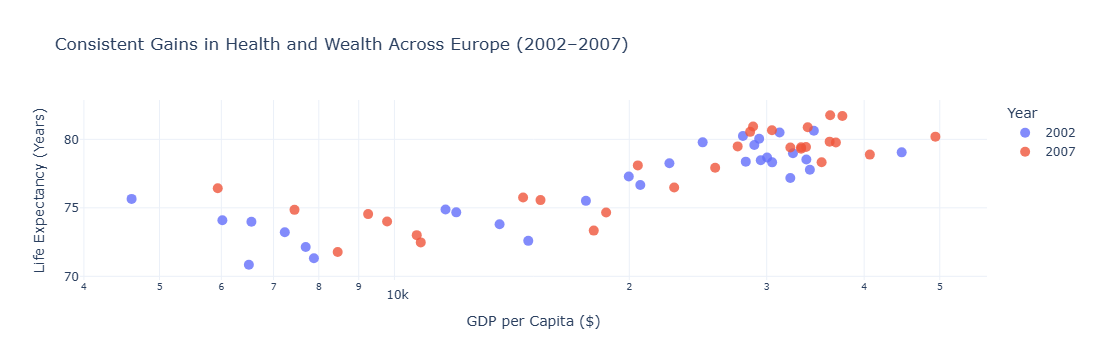

In [20]:
europe_df = df[(df['continent'] == 'Europe') & (df['year'].isin([2002, 2007]))].copy()

fig = px.scatter(
    europe_df, 
    x="gdpPercap", 
    y="lifeExp",
    color=europe_df['year'].astype(str), 
    hover_name="country",
    log_x=True,  # <--- FIX: Rule 4 applied
    title="Consistent Gains in Health and Wealth Across Europe (2002–2007)", # <--- FIX: Rule 5 applied
    labels={"gdpPercap": "GDP per Capita ($)", "lifeExp": "Life Expectancy (Years)", "color": "Year"},
    template="plotly_white"
)

fig.update_traces(marker=dict(size=10, opacity=0.8))
fig.show()

Insight:European countries generally shifted upward and to the right from 2002 to 2007.
This indicates simultaneous improvements in both GDP per capita and life expectancy.
The movement suggests continued economic growth alongside better health outcomes across the region.
Higher-income countries remain clustered at high life expectancy levels, showing relative stability.
Overall, Europe demonstrates consistent and balanced development during this period.

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


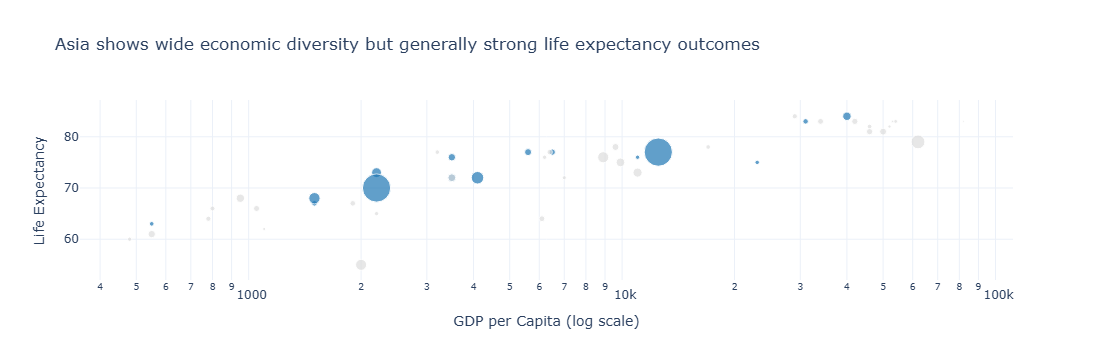

In [6]:
import pandas as pd
import plotly.express as px

# Load data
df = pd.read_csv('gapminder.csv')

# Choose continent to highlight
highlight_continent = 'Asia'

# Create color column
df['Highlight'] = df['Continent'].apply(
    lambda x: highlight_continent if x == highlight_continent else 'Other'
)

# Custom colors: highlight + grey
color_map = {
    highlight_continent: '#1f77b4',
    'Other': '#DDDDDD'
}

# Bubble chart
fig = px.scatter(
    df,
    x='GDP_per_capita',
    y='Life_expectancy',
    size='Population',
    color='Highlight',
    color_discrete_map=color_map,
    hover_name='Country',
    log_x=True,
    title=f'{highlight_continent} shows wide economic diversity but generally strong life expectancy outcomes',
    labels={
        'GDP_per_capita': 'GDP per Capita (log scale)',
        'Life_expectancy': 'Life Expectancy'
    }
)

# Add annotation
fig.add_annotation(
    x=15000,
    y=78,
    text='Asian countries span a wide GDP range<br>while maintaining relatively high life expectancy',
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    template='plotly_white',
    showlegend=False
)

fig.show()

Insight: Asian countries display large variation in GDP per capita across the region.
Despite income differences, many countries maintain relatively high life expectancy.
This suggests health outcomes are not determined by income alone.
Several Asian countries outperform peers at similar GDP levels.
The region combines both emerging and highly developed economies.